# CH 5 - 2 — Hypothesis Tests versus Informal Inference

## Illustration pédagogique EBTA avec exemples trading + Python

Objectif du cahier : comprendre pourquoi une stratégie profitable en backtest ne prouve pas automatiquement l'existence d'un edge.

L'idée centrale :

> Le trader informel regarde une courbe profitable et dit : « ça marche ».

> Le trader scientifique demande : « est-ce que ce profit est suffisamment improbable sous l'hypothèse du hasard ? »

Ce notebook illustre la différence entre :

- l'inférence informelle,
- le test d'hypothèse formel,
- la p-value,
- l'hypothèse nulle H0,
- et la logique de falsification appliquée au trading objectif.

## 1. Le piège : « la stratégie a gagné, donc elle a un edge »

Imaginons une stratégie qui donne :

```text
Profit moyen par trade = +0.12R
Nombre de trades = 100
```

L'inférence informelle conclut rapidement :

```text
La moyenne est positive, donc la stratégie est bonne.
```

Mais une stratégie sans edge peut aussi produire une moyenne positive simplement par chance.

La vraie question devient donc :

> Si cette stratégie n'avait aucun edge réel, quelle serait la probabilité d'obtenir un résultat aussi bon uniquement par hasard ?

## 2. Hypothèse nulle et hypothèse alternative

Dans le cadre du trading :

```text
H0 : la stratégie n'a aucun edge.
     Son rendement moyen réel est égal à 0.

H1 : la stratégie a un edge.
     Son rendement moyen réel est supérieur à 0.
```

Le trader scientifique part toujours de H0.

Autrement dit :

> Par défaut, la stratégie ne vaut rien. À elle de rendre cette hypothèse peu crédible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Paramètres généraux
n_trades = 100

# Exemple : rendements en R d'une stratégie observée
# Moyenne légèrement positive, mais bruit important
trades = np.random.normal(loc=0.12, scale=1.0, size=n_trades)

mean_return = np.mean(trades)
std_return = np.std(trades, ddof=1)

print(f"Moyenne observée : {mean_return:.4f} R")
print(f"Écart-type : {std_return:.4f} R")

Moyenne observée : 0.0162 R
Écart-type : 0.9082 R


## 3. Test t de Student

On teste si la moyenne des trades est significativement supérieure à 0.

Ici, on utilise un test unilatéral :

```text
H0 : moyenne = 0
H1 : moyenne > 0
```

Interprétation :

- si `p-value < 0.05`, on rejette H0 ;
- si `p-value >= 0.05`, on ne rejette pas H0.

Attention : rejeter H0 ne prouve pas absolument que la stratégie est bonne. Cela signifie seulement que le hasard devient une explication moins crédible.

In [2]:
# Test t bilatéral fourni par scipy
t_stat, p_value_two_sided = stats.ttest_1samp(trades, popmean=0)

# Conversion en test unilatéral : H1 = moyenne > 0
if mean_return > 0:
    p_value_one_sided = p_value_two_sided / 2
else:
    p_value_one_sided = 1 - (p_value_two_sided / 2)

print(f"Moyenne observée : {mean_return:.4f} R")
print(f"t-stat : {t_stat:.4f}")
print(f"p-value unilatérale : {p_value_one_sided:.4f}")

alpha = 0.05

if p_value_one_sided < alpha:
    print("Décision : H0 rejetée. La stratégie mérite une étude plus approfondie.")
else:
    print("Décision : H0 non rejetée. La performance peut être due au hasard.")

Moyenne observée : 0.0162 R
t-stat : 0.1779
p-value unilatérale : 0.4296
Décision : H0 non rejetée. La performance peut être due au hasard.


## 4. Visualiser l'étalon du hasard

On va simuler des milliers de stratégies sans edge.

Sous H0 :

```text
moyenne réelle = 0
```

Puis on compare la moyenne observée de notre stratégie à cette distribution de moyennes possibles par hasard.

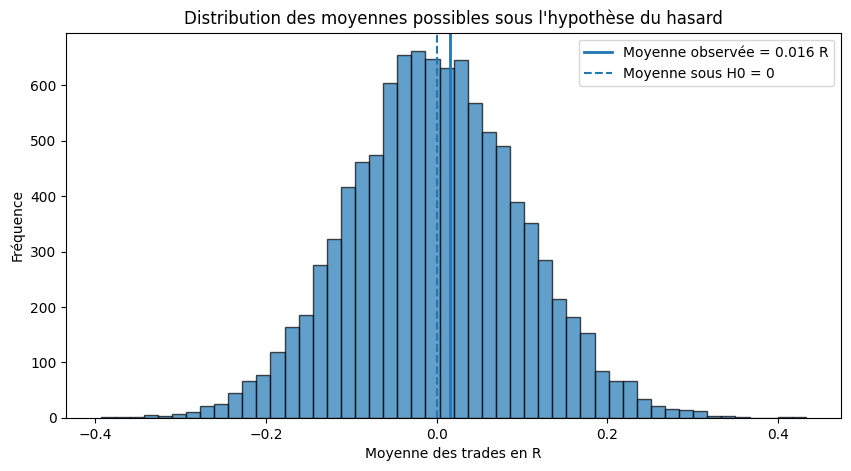

In [3]:
np.random.seed(42)

n_simulations = 10_000
simulated_means = []

for _ in range(n_simulations):
    random_trades = np.random.normal(loc=0, scale=1.0, size=n_trades)
    simulated_means.append(np.mean(random_trades))

simulated_means = np.array(simulated_means)

plt.figure(figsize=(10, 5))
plt.hist(simulated_means, bins=50, alpha=0.7, edgecolor="black")
plt.axvline(mean_return, linewidth=2, label=f"Moyenne observée = {mean_return:.3f} R")
plt.axvline(0, linestyle="--", label="Moyenne sous H0 = 0")
plt.title("Distribution des moyennes possibles sous l'hypothèse du hasard")
plt.xlabel("Moyenne des trades en R")
plt.ylabel("Fréquence")
plt.legend()
plt.show()

## 5. Stratégie sans edge mais profitable par chance

Maintenant, simulons une stratégie dont la vraie moyenne est 0.

Elle n'a donc aucun edge théorique.

Mais dans un échantillon limité, elle peut quand même sortir positive.

In [4]:
np.random.seed(7)

fake_strategy = np.random.normal(loc=0, scale=1.0, size=100)

fake_mean = np.mean(fake_strategy)
fake_t, fake_p_two_sided = stats.ttest_1samp(fake_strategy, popmean=0)

if fake_mean > 0:
    fake_p_one_sided = fake_p_two_sided / 2
else:
    fake_p_one_sided = 1 - (fake_p_two_sided / 2)

print(f"Moyenne observée : {fake_mean:.4f} R")
print(f"p-value unilatérale : {fake_p_one_sided:.4f}")

if fake_p_one_sided < 0.05:
    print("Décision : H0 rejetée.")
else:
    print("Décision : H0 non rejetée. La stratégie peut très bien être une illusion statistique.")

Moyenne observée : 0.0121 R
p-value unilatérale : 0.4532
Décision : H0 non rejetée. La stratégie peut très bien être une illusion statistique.


## 6. L'erreur logique du trader informel

Le trader informel raisonne souvent comme ceci :

```text
Si une stratégie a un edge, alors elle peut produire du profit.
Cette stratégie a produit du profit.
Donc elle a un edge.
```

C'est une erreur logique : l'affirmation du conséquent.

Forme générale :

```text
Si A alors B.
B est vrai.
Donc A est vrai.
```

Ce raisonnement est faux, car B peut être vrai pour une autre raison.

En trading : le profit peut venir du talent, mais aussi de la chance.

## 7. La logique correcte du test d'hypothèse

Le test d'hypothèse raisonne plutôt ainsi :

```text
Si la stratégie n'a aucun edge,
alors un tel niveau de profit devrait être très rare.

Or ce niveau de profit est observé.

Donc l'hypothèse 'aucun edge' devient peu crédible.
```

Ce n'est pas une preuve absolue.

C'est une décision rationnelle sous incertitude.

## 8. Comparaison de deux stratégies

On va comparer deux stratégies :

- Stratégie A : moyenne plus élevée, mais beaucoup de bruit ;
- Stratégie B : moyenne plus faible, mais plus stable.

Le but est de montrer qu'une moyenne plus élevée n'est pas toujours statistiquement plus crédible.

In [5]:
np.random.seed(123)

n = 200

strategy_a = np.random.normal(loc=0.08, scale=1.5, size=n)
strategy_b = np.random.normal(loc=0.05, scale=0.4, size=n)

def hypothesis_test(trades):
    mean = np.mean(trades)
    std = np.std(trades, ddof=1)
    t_stat, p_two = stats.ttest_1samp(trades, popmean=0)

    if mean > 0:
        p_one = p_two / 2
    else:
        p_one = 1 - (p_two / 2)

    return mean, std, t_stat, p_one

results = []

for name, strategy in {
    "Stratégie A": strategy_a,
    "Stratégie B": strategy_b,
}.items():
    mean, std, t_stat, p_value = hypothesis_test(strategy)
    results.append({
        "Stratégie": name,
        "Moyenne": mean,
        "Écart-type": std,
        "t-stat": t_stat,
        "p-value": p_value,
        "Décision": "H0 rejetée" if p_value < 0.05 else "H0 non rejetée"
    })

pd.DataFrame(results)

,Stratégie,Moyenne,Écart-type,t-stat,p-value,Décision
0,Stratégie A,0.085680,1.582535,0.76567,0.22239,H0 non rejetée
1,Stratégie B,0.004255,0.371271,0.16209,0.43570,H0 non rejetée


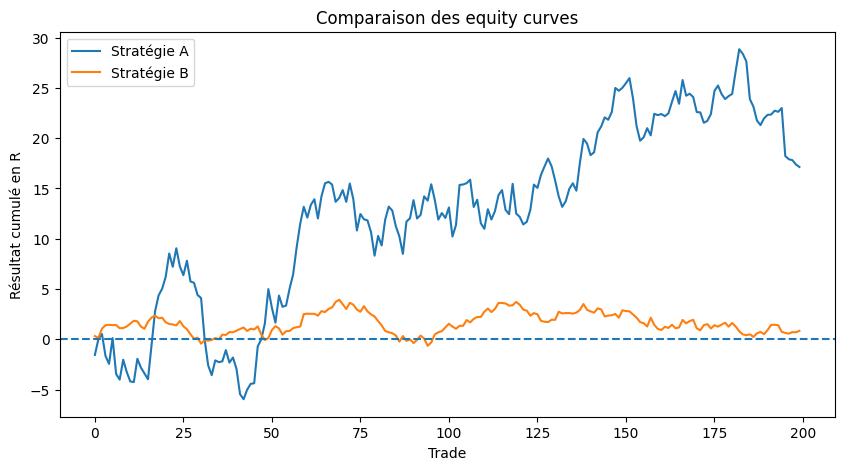

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(strategy_a), label="Stratégie A")
plt.plot(np.cumsum(strategy_b), label="Stratégie B")
plt.axhline(0, linestyle="--")
plt.title("Comparaison des equity curves")
plt.xlabel("Trade")
plt.ylabel("Résultat cumulé en R")
plt.legend()
plt.show()

## 9. Fonction de décision EBTA

On peut formaliser une règle simple :

```text
Si p-value < 0.05 :
    H0 rejetée, la stratégie mérite une étude plus approfondie.

Sinon :
    H0 non rejetée, pas assez de preuve contre le hasard.
```

Attention : une p-value inférieure à 0.05 n'autorise pas à trader aveuglément.

Elle indique seulement que la stratégie a passé un premier filtre statistique.

In [7]:
def ebta_decision_rule(p_value, alpha=0.05):
    if p_value < alpha:
        return "H0 rejetée : la règle mérite une étude plus approfondie."
    else:
        return "H0 non rejetée : performance insuffisante pour conclure à un edge."

print(ebta_decision_rule(0.03))
print(ebta_decision_rule(0.21))

H0 rejetée : la règle mérite une étude plus approfondie.
H0 non rejetée : performance insuffisante pour conclure à un edge.


## 10. Application directe à ton trading

Quand tu backtestes une règle, ne demande pas seulement :

```text
Est-ce que ça gagne ?
```

Demande plutôt :

```text
Est-ce que ça gagne plus que ce qu'une règle sans edge pourrait gagner par chance ?
```

Et surtout :

```text
Est-ce que mes règles étaient définies avant de regarder le résultat ?
Ou est-ce que j'ai ajusté mon interprétation après coup ?
```

Si tu ajustes après coup, tu n'es plus dans la science.

Tu es dans le storytelling.

## 11. À retenir absolument

Le trader subjectif cherche des confirmations :

```text
Où est-ce que mon setup a bien marché ?
```

Le trader scientifique cherche à falsifier :

```text
Est-ce que mon setup peut survivre à l'hypothèse qu'il ne vaut rien ?
```

Phrase clé :

> On ne prouve pas qu'une stratégie a du talent. On rejette, avec un certain niveau de confiance, l'explication du hasard.

Donc :

```text
Profit passé ≠ edge
Belle equity curve ≠ edge
Quelques bons exemples ≠ edge
Backtest positif ≠ edge
```

Un edge commence à devenir crédible lorsque la performance observée est trop extrême pour être expliquée raisonnablement par le hasard.